In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 300
plt.style.use("seaborn-v0_8-pastel")
sns.set_palette([sns.color_palette()[i] for i in [0, 2, 4, 3, 0, 1, 5]])

data = pd.read_csv("latency-nots.csv")
data["Speedup"] = 0

models = set(data["Model"])
passes = set(data["Pass"])
frameworks = set(data["Framework"])
base_framework = "TF-XLA"

In [2]:
for model in models:
    for pas in passes:
        base = data.loc[
            (data["Model"] == model) & 
            (data["Pass"] == pas) & 
            (data["Framework"] == base_framework), 
            "Time"
        ].item()
        for framework in frameworks:
            time = data.loc[
                (data["Model"] == model) & 
                (data["Pass"] == pas) & 
                (data["Framework"] == framework), 
                "Time"
            ].item()
            data.loc[
                (data["Model"] == model) & 
                (data["Pass"] == pas) & 
                (data["Framework"] == framework), 
                "Speedup"
            ] = base / time
            
gradient_data = data[data["Pass"] == "Gradient"]
total_data = data[data["Pass"] == "Total"]

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
          Time   Pass          Model    Framework   Speedup
8    24.904834  Total      ResNet152  TorchDynamo  0.875775
9    21.811020  Total      ResNet152       TF-XLA  1.000000
10   27.026660  Total      ResNet152          JAX  0.807019
11   18.361000  Total      ResNet152        SMART  1.187899
20   19.618990  Total      ResNet101  TorchDynamo  1.286808
21   25.245870  Total      ResNet101       TF-XLA  1.000000
22   19.429650  Total      ResNet101          JAX  1.299348
23   14.272638  Total      ResNet101        SMART  1.768830
32   23.732392  Total  WideResNet101  TorchDynamo  1.795382
33   42.608700  Total  WideResNet101       TF-XLA  1.000000
34   26.513160  Total  WideResNet101          JAX  1.607077
35   23.848488  Total  WideResNet101        SMART  1.786642
44   13.449026  Total          VGG16  TorchDynamo  1.245447
45   16.750050  Total          VGG16       TF-XLA 

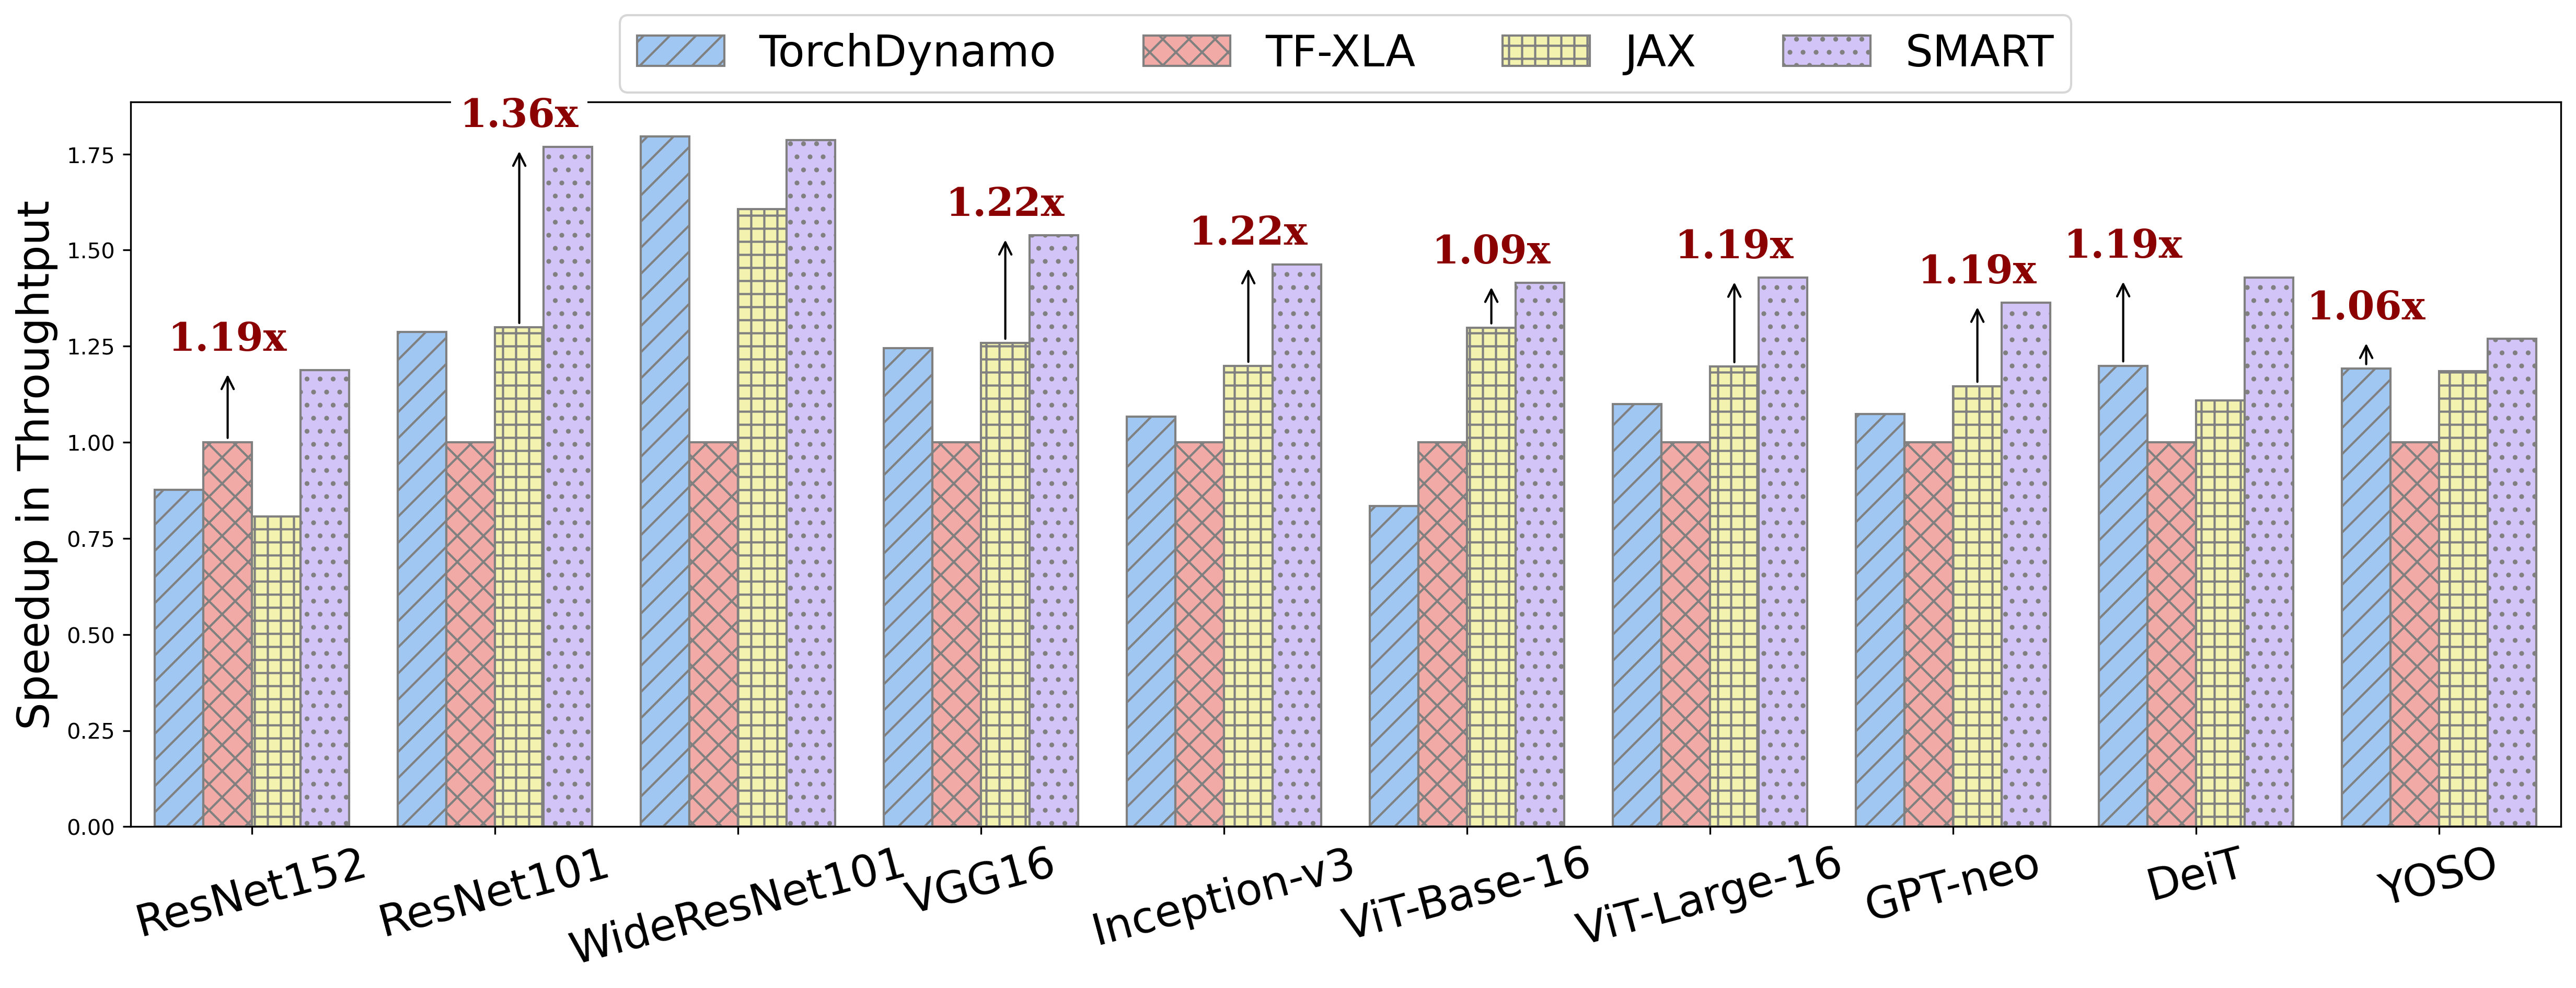

In [3]:
plt.rcParams["figure.figsize"] = (len(models) * 2, 6)

hatches = ["xx", "++", "..", "//"]
assert len(hatches) == len(frameworks)

barplot = sns.barplot(total_data, x="Model", y="Speedup", hue="Framework")
plt.xticks(rotation=15, fontsize=20)
plt.ylabel("Speedup in Throughtput", fontsize=20)
plt.xlabel(None)

for i, bar in enumerate(barplot.patches):
    print(i)
    bar.set_hatch(hatches[i // len(models)-1])
    bar.set_edgecolor("gray")
    
legend = plt.legend(loc="upper center", ncol=5, bbox_to_anchor=(0.5, 1.15), fontsize=20)

fd={ 'size': 18}
ap=dict(facecolor='red', arrowstyle='->', linewidth=1)
start = 1.0
end = 1.18789
x = -0.1
vratio = end/start
plt.annotate('', xy=(x, end), xytext=(x, start),
             arrowprops=ap,
             fontsize=14, ha='center',zorder=6)
plt.text(x, end + 0.08, f"{vratio:.2f}x",fontproperties='DejaVu Serif',color='#8B0000',fontweight='bold', ha='center', va='center',fontdict=fd, bbox=dict(edgecolor='None',facecolor='white', alpha=1),zorder=13)

start = 1.299
end =1.7688
x = 1.1
vratio = end/start
plt.annotate('', xy=(x, end), xytext=(x, start),
             arrowprops=ap,
             fontsize=14, ha='center',zorder=6)
plt.text(x, end + 0.08, f"{vratio:.2f}x",fontproperties='DejaVu Serif',color='#8B0000',fontweight='bold', ha='center', va='center',fontdict=fd, bbox=dict(edgecolor='None',facecolor='white', alpha=1),zorder=13)

start = 1.258
end =1.538
x = 3.1
vratio = end/start
plt.annotate('', xy=(x, end), xytext=(x, start),
             arrowprops=ap,
             fontsize=14, ha='center',zorder=6)
plt.text(x, end + 0.08, f"{vratio:.2f}x",fontproperties='DejaVu Serif',color='#8B0000',fontweight='bold', ha='center', va='center',fontdict=fd, bbox=dict(edgecolor='None',facecolor='white', alpha=1),zorder=13)

start = 1.198
end =1.463
x = 4.1
vratio = end/start
plt.annotate('', xy=(x, end), xytext=(x, start),
             arrowprops=ap,
             fontsize=14, ha='center',zorder=6)
plt.text(x, end + 0.08, f"{vratio:.2f}x",fontproperties='DejaVu Serif',color='#8B0000',fontweight='bold', ha='center', va='center',fontdict=fd, bbox=dict(edgecolor='None',facecolor='white', alpha=1),zorder=13)

start = 1.298
end =1.4147
x = 5.1
vratio = end/start
plt.annotate('', xy=(x, end), xytext=(x, start),
             arrowprops=ap,
             fontsize=14, ha='center',zorder=6)
plt.text(x, end + 0.08, f"{vratio:.2f}x",fontproperties='DejaVu Serif',color='#8B0000',fontweight='bold', ha='center', va='center',fontdict=fd, bbox=dict(edgecolor='None',facecolor='white', alpha=1),zorder=13)

start = 1.197
end =1.4280
x = 6.1
vratio = end/start
plt.annotate('', xy=(x, end), xytext=(x, start),
             arrowprops=ap,
             fontsize=14, ha='center',zorder=6)
plt.text(x, end + 0.08, f"{vratio:.2f}x",fontproperties='DejaVu Serif',color='#8B0000',fontweight='bold', ha='center', va='center',fontdict=fd, bbox=dict(edgecolor='None',facecolor='white', alpha=1),zorder=13)

start = 1.146
end =1.3628
x = 7.1
vratio = end/start
plt.annotate('', xy=(x, end), xytext=(x, start),
             arrowprops=ap,
             fontsize=14, ha='center',zorder=6)
plt.text(x, end + 0.08, f"{vratio:.2f}x",fontproperties='DejaVu Serif',color='#8B0000',fontweight='bold', ha='center', va='center',fontdict=fd, bbox=dict(edgecolor='None',facecolor='white', alpha=1),zorder=13)

start = 1.1991
end =1.4291
x = 7.7
vratio = end/start
plt.annotate('', xy=(x, end), xytext=(x, start),
             arrowprops=ap,
             fontsize=14, ha='center',zorder=6)
plt.text(x, end + 0.08, f"{vratio:.2f}x",fontproperties='DejaVu Serif',color='#8B0000',fontweight='bold', ha='center', va='center',fontdict=fd, bbox=dict(edgecolor='None',facecolor='white', alpha=1),zorder=13)

start = 1.1919
end =1.2688
x = 8.7
vratio = end/start
plt.annotate('', xy=(x, end), xytext=(x, start),
             arrowprops=ap,
             fontsize=14, ha='center',zorder=6)
plt.text(x, end + 0.08, f"{vratio:.2f}x",fontproperties='DejaVu Serif',color='#8B0000',fontweight='bold', ha='center', va='center',fontdict=fd, bbox=dict(edgecolor='None',facecolor='white', alpha=1),zorder=13)

pd.set_option('display.max_rows', None)  # 显示所有行
pd.set_option('display.max_columns', None)  # 显示所有列
print(total_data)
plt.savefig("entire-gpu.pdf", bbox_inches="tight", dpi=300, pad_inches=0.1)

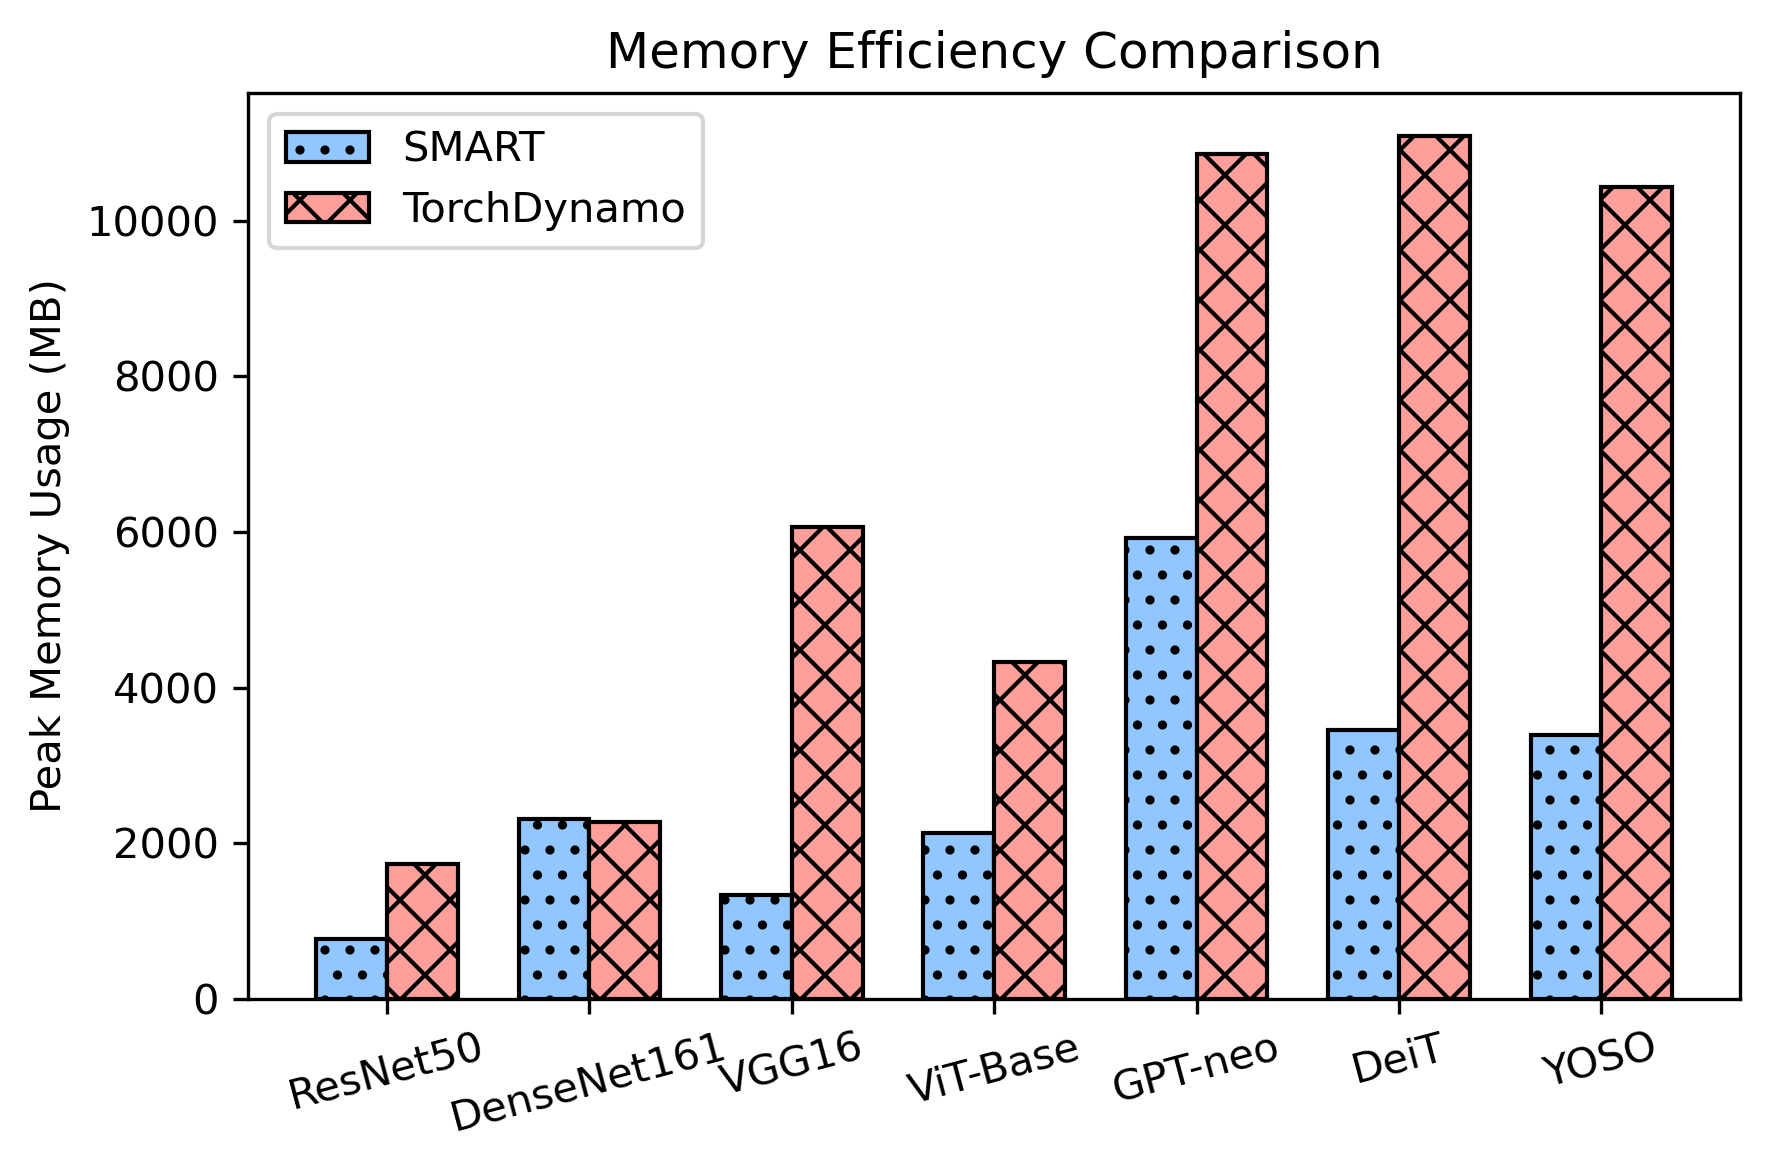

In [4]:
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams["figure.dpi"] = 300
plt.style.use("seaborn-v0_8-pastel")
sns.set_palette([sns.color_palette()[i] for i in [0, 2, 4, 1, 3, 5]])

# Model names
models = ['ResNet50', 'DenseNet161','VGG16', 'ViT-Base', 'GPT-neo', "DeiT", "YOSO"]

# Defining the data
models = ['ResNet50', 'DenseNet161', 'VGG16', 'ViT-Base', 'GPT-neo', "DeiT", "YOSO"]
nabla_optim_scores = [771.5, 2303.5,  1326.3, 2131.1, 5918, 3458, 3386]
torch_dynamo_scores = [1731.5, 2275.8, 6066.6, 4323.2, 10862, 11088, 10428]

# Setting the positions and width for the bars
positions = np.arange(len(models))
bar_width = 0.35

# Creating the plot
fig, ax = plt.subplots(figsize=(6, 4))  # Adjusting the figure size for better visibility

fig.set_edgecolor('black')

# Plotting the data
bars_nabla_optim = ax.bar(positions - bar_width/2, nabla_optim_scores, bar_width, label='SMART', hatch="..", edgecolor="black")
bars_torch_dynamo = ax.bar(positions + bar_width/2, torch_dynamo_scores, bar_width, label='TorchDynamo', hatch="xx", edgecolor="black")

# Adding some final touches
ax.set_xticks(positions)
ax.set_xticklabels(models, rotation=15)
ax.set_ylabel('Peak Memory Usage (MB)')
ax.set_title('Memory Efficiency Comparison')
ax.legend()
ax.grid(False)
ax.set_facecolor('white')  # Ensuring the background is white

# Ensuring the plot itself has a black border
for spine in ax.spines.values():
    spine.set_edgecolor('black')

# Displaying the plot
plt.tight_layout()
#plt.show()
plt.savefig("mem-comparison.pdf", bbox_inches="tight", dpi=300, pad_inches=0.1)